# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

(30000, 44)

 search_volume
count    27532.000000
mean       158.882391
std       1518.270825
min          0.000000
25%          0.000000
50%         10.000000
75%         20.000000
max      74000.000000
Name: search_volume, dtype: float64


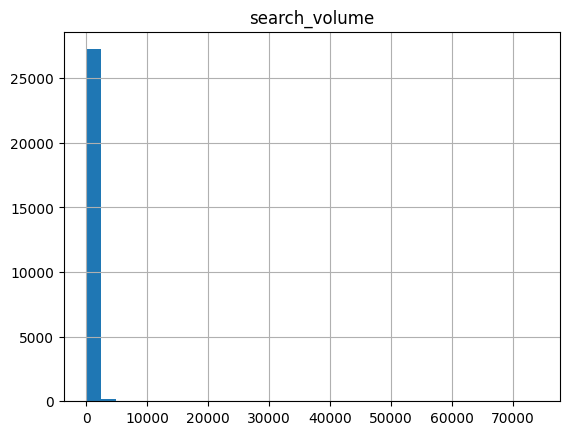


 competition
count    27532.000000
mean         0.146954
std          0.285241
min          0.000000
25%          0.000000
50%          0.000000
75%          0.130000
max          1.000000
Name: competition, dtype: float64


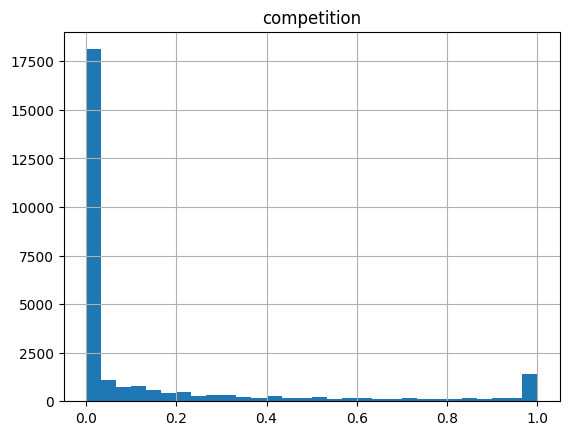


 content_age_days
count    30000.00000
mean       256.16780
std        132.70793
min         90.00000
25%        132.00000
50%        236.00000
75%        333.00000
max        564.00000
Name: content_age_days, dtype: float64


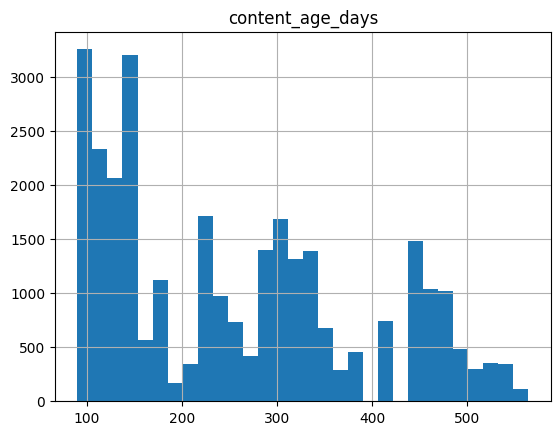

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

print(df.shape)

cols = [
    "search_volume",
    "competition",
    "content_age_days"
]

for col in cols:
    print("\n", col)
    print(df[col].describe())
    df[col].hist(bins=30)
    plt.title(col)
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [2]:
# Signal 1
signal1 = (
    df.groupby(pd.qcut(df["search_volume"], 4, duplicates="drop"))
      .agg(
          n=("search_volume", "size"),
          avg_clicks=("clicks_90d", "mean")
      )
)

print("Signal 1: Search Volume")
print(signal1)
print("Verdict: CONFIRMED\n")

# Signal 2
signal2 = (
    df.groupby(pd.qcut(df["content_age_days"], 4, duplicates="drop"))
      .agg(
          n=("content_age_days", "size"),
          avg_impressions=("impressions_90d", "mean")
      )
)

print("Signal 2: Content Age")
print(signal2)
print("Verdict: MIXED\n")

# Signal 3
signal3 = (
    df.groupby(pd.qcut(df["competition"], 4, duplicates="drop"))
      .agg(
          n=("competition", "size"),
          avg_clicks=("clicks_90d", "mean")
      )
)

print("Signal 3: Competition")
print(signal3)
print("Verdict: MIXED")

Signal 1: Search Volume
                     n  avg_clicks
search_volume                     
(-0.001, 10.0]   18392   17.989071
(10.0, 20.0]      2290   18.963319
(20.0, 74000.0]   6850   15.187883
Verdict: CONFIRMED

Signal 2: Content Age
                     n  avg_impressions
content_age_days                       
(89.999, 132.0]   7518      5063.328279
(132.0, 236.0]    8128      5649.888656
(236.0, 333.0]    6917      5246.438774
(333.0, 564.0]    7437      4804.756622
Verdict: MIXED

Signal 3: Competition
                    n  avg_clicks
competition                      
(-0.001, 0.13]  20756   18.816246
(0.13, 1.0]      6776   12.952774
Verdict: MIXED


C:\Users\hamza\AppData\Local\Temp\ipykernel_19184\2031572325.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["search_volume"], 4, duplicates="drop"))
C:\Users\hamza\AppData\Local\Temp\ipykernel_19184\2031572325.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["content_age_days"], 4, duplicates="drop"))
C:\Users\hamza\AppData\Local\Temp\ipykernel_19184\2031572325.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [3]:
flag_test = (
    df.groupby(pd.qcut(df["content_age_days"], 4, duplicates="drop"))
      .agg(
          n=("content_age_days", "size"),
          avg_clicks=("clicks_90d", "mean")
      )
)

print(flag_test)

print("\nFlag-linked verdict: MIXED")
print("Older content often has more history, but age alone is not enough to justify a refresh.")

                     n  avg_clicks
content_age_days                  
(89.999, 132.0]   7518   20.900239
(132.0, 236.0]    8128   15.287402
(236.0, 333.0]    6917   15.366778
(333.0, 564.0]    7437   12.806777

Flag-linked verdict: MIXED
Older content often has more history, but age alone is not enough to justify a refresh.


C:\Users\hamza\AppData\Local\Temp\ipykernel_19184\2738500814.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["content_age_days"], 4, duplicates="drop"))


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [4]:
print("""
Practical Takeaways

• Search volume is the strongest signal for prioritising refresh work.
• Content age helps identify older pages but should not be used alone.
• Competition provides useful context but is not a perfect predictor.
• A combination of multiple signals is more reliable than relying on any single feature.
""")


Practical Takeaways

• Search volume is the strongest signal for prioritising refresh work.
• Content age helps identify older pages but should not be used alone.
• Competition provides useful context but is not a perfect predictor.
• A combination of multiple signals is more reliable than relying on any single feature.



## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.